- MSSV: 25410291
- Họ Tên: Đinh Xuân Sâm
- GDrive: [IE313 > notebooks](https://drive.google.com/drive/folders/1nap2ahjmAj6aj1cm6xr5nZDrBFeBjc00)
- Github: [sam-uit/IE313](https://github.com/sam-uit/IE313)


# Buổi 07 - Bài 06 - Phát Triển Mô Hình

Mục tiêu:

- Vận dụng hồi quy tuyế tính đơn và đa biến.
- Biết đánh giá mô hình dùng trực quan.
- Vận dùng hồi quy đa thức và kỹ thuật Pipeline.
- Áp dụng thang đo *R-squared* và *MSE* dùng để đánh giá tập mẫu.

Nội Dung:

1. Phát triển mô hình.
2. Hồi quy tuyến tính đơn biến.
3. Hồi quy tuyến tính đa biến.
4. Đánh giá mô hình dùng trực quan.
5. Hồi quy đa thức.
6. Kỹ thuật Pipeline.
7. Thang đo *MSE* và *R-squared* ($R^2$ -- $R^2$).
8. Đánh giá.

Tóm tắt:

- Đặt vấn đề (Bài 1):
    - *Chúng ta nên bán xe đã qua sử dụng với giá bao nhiêu?*
- Hướng giải quyết (Bài 2):
    - *Tiền xử lý dữ liệu liên quan để phục vụ phân tích.*
- Phân tích thăm dò (Bài 5):
    - *Những đặc điểm nào có ảnh hưởngg nhất đến giá xe?*
- Phát triển mô hình để dự đoán (Bài 6):
    - *Cúng ta đã **xác định giá hợp lý** cho xe đã qua sử dụng như thế nào?*

## 0. Load Dataset

### Import libraries

In [91]:
# import numpy & panda
import numpy as np
import pandas as pd

In [92]:
# import matplotlib
import matplotlib.pyplot as plt

In [93]:
# import seaborn
import seaborn as sns

### Data file

In [94]:
dataset_theory_url = "https://raw.githubusercontent.com/datasethub/ds105/master/Model_Dataset.csv"
dataset_theory_file = "Model_Dataset.csv"
dataset_lab_url ="https://raw.githubusercontent.com/datasethub/ds105/master/Model_Dataset_Lab.csv"
dataset_lab_file = "Model_Dataset_Lab.csv"

In [95]:
# download the dataset file
import requests

try:
    dataset_theory_response = requests.get(dataset_theory_url)

    with open(dataset_theory_file, "wb") as file:
        file.write(dataset_theory_response.content)

    dataset_lab_response = requests.get(dataset_lab_url)
    with open(dataset_lab_file, "wb") as file_lab:
        file_lab.write(dataset_lab_response.content)

    print("Download complete!")
except:
    print("Download failed!")


Download complete!


### `read_csv`

In [96]:
# read from a local file
df_theory = pd.read_csv(dataset_theory_file)

In [97]:
df_theory

,Unnamed: 0,curb-weight,engine-size,length,width,horsepower,city-mpg,highway-mpg,wheel-base,bore,drive-wheels,price
0,0,2548,130,0.811148,0.890278,111.0,21,27,88.6,3.47,rwd,13495.0
1,1,2548,130,0.811148,0.890278,111.0,21,27,88.6,3.47,rwd,16500.0
2,2,2823,152,0.822681,0.909722,154.0,19,26,94.5,2.68,rwd,16500.0
3,3,2337,109,0.848630,0.919444,102.0,24,30,99.8,3.19,fwd,13950.0
4,4,2824,136,0.848630,0.922222,115.0,18,22,99.4,3.19,4wd,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,2952,141,0.907256,0.956944,114.0,23,28,109.1,3.78,rwd,16845.0
197,197,3049,141,0.907256,0.955556,160.0,19,25,109.1,3.78,rwd,19045.0
198,198,3012,173,0.907256,0.956944,134.0,18,23,109.1,3.58,rwd,21485.0
199,199,3217,145,0.907256,0.956944,106.0,26,27,109.1,3.01,rwd,22470.0


## Xây Dựng Mô Hình

## Hồi Quy Tuyến Tính Đơn Biến

### Mô Hình

- $x$: biến độc lập (**predictor**)
- $y$: biến phụ thuộc (**target**)

$$y = b_0 + b_{1}x$$

- $b_0$: **intercept**
- $b_1$: **slope**

### Dự Đoán

### Xây Dựng (fit)

- Là 1 đường thẳng, cố gắng làm hài lòng tất cả các điểm phổ biến.

In [98]:
# import bảo bối
from sklearn.linear_model import LinearRegression
m1 = LinearRegression()

In [99]:
# lấy ra các biến
X1 = df_theory[['highway-mpg']]
y = df_theory['price']

In [100]:
# xây dựng mô hình
m1.fit(X1, y)

LinearRegression()

In [101]:
b0 = m1.intercept_
b1 = m1.coef_
print(f'b0 = {b0}, b1 = {b1}')

b0 = 38423.3058581574, b1 = [-821.73337832]


In [102]:
x = 20
y = b0 + b1 * x
y

array([21988.63829172])

In [103]:
# dự đoán
m1.predict([[20]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21988.63829172])

In [104]:
# dự doán, tham số là np.array
m1.predict(np.array([[20]]))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21988.63829172])

In [105]:
# dự doán, tham số là np.array
m1.predict(np.array([[20], [15]]))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21988.63829172, 26097.30518333])

In [106]:
# dự đoán
yhat = m1.predict(X1)

## Hồi Quy Tuyến Tính Đa Biến

$$Y = b_0 + b_{1}x_{1} + b_{2}x_{2} + b_{3}x_{3} + \ldots$$

- $b_0$: intercept (X = 0)
- $b_1$: coefficient hoặc parameter của $x_1$
- $b_2$: ... của $x_2$

### Xây Dựng

In [107]:
# chọn biến
X2 = df_theory[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df_theory['price']

# khai báo mô hình
m2 = LinearRegression()

# fit
m2.fit(X2, y)

LinearRegression()

In [108]:
b0 = m2.intercept_
b0

np.float64(-15806.62462632922)

In [109]:
m2.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

In [110]:
m2.predict([[111, 2548, 130, 27]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13699.11161184])

In [111]:
m2.predict([[154, 2823, 152, 26]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([19051.65470233])

In [112]:
df_theory[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg', 'price']]

,horsepower,curb-weight,engine-size,highway-mpg,price
0,111.0,2548,130,27,13495.0
1,111.0,2548,130,27,16500.0
2,154.0,2823,152,26,16500.0
3,102.0,2337,109,30,13950.0
4,115.0,2824,136,22,17450.0
...,...,...,...,...,...
196,114.0,2952,141,28,16845.0
197,160.0,3049,141,25,19045.0
198,134.0,3012,173,23,21485.0
199,106.0,3217,145,27,22470.0


In [113]:
# dự đoán
yhat = m2.predict(X2)

## Đánh Giá Mô Hình Trực Quan

Các mô hình:

- Regression plot
- Residual plot
- Distribution plot

### Distribution plot

In [114]:
# distribution plot
y

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0
...,...
196,16845.0
197,19045.0
198,21485.0
199,22470.0


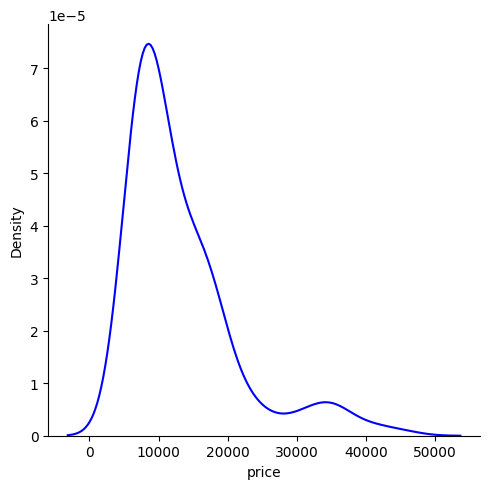

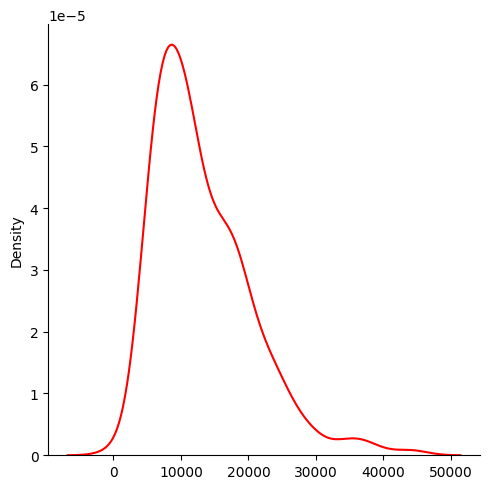

In [115]:
# distribution plot cho y thực tế
ax1 = sns.displot(
    y,
    kind='kde',
    color='blue'
)

# distribution plot cho y dự đoán
ax2 = sns.displot(
    yhat,
    kind='kde',
    color='red'
)

<Axes: xlabel='price', ylabel='Density'>

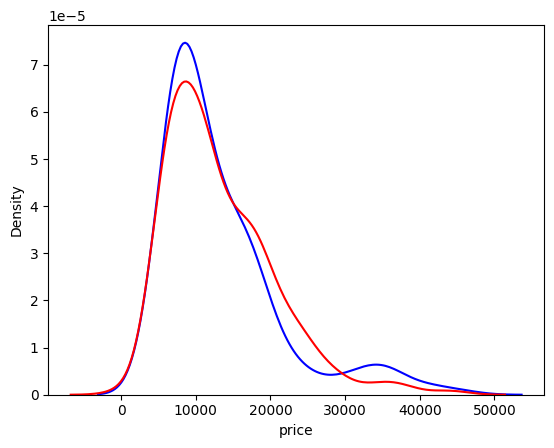

In [116]:
# Đối chiếu 2 chuỗi giá trị
ax1 = sns.kdeplot(data=df_theory, x='price', color="blue")
sns.kdeplot(yhat, color='red', ax=ax1)

### Nhận Xét Mô Hình

- Mô hình có sự sai khác ở các loại xe có `price` lớn (~10000 - 40000).

### Bài Tập

- p52

## Hồi Quy Đa Thức

Polynomial regression

- Mộ trường hợp đặc biệt của mô hình hồi quy tuyến tính tổng quát.
- Mối quan hệ cong phi tuyến (curvilinear)
- Đường cong: cố gắng hài lòng tất cả các điểm (tham gia vào công thức/mô hình).

Quan hệ cong phi tuyến:

- Bình phương.
- Thiết lập các bậc cao hơn cho biến độc lập.

### Cong Phi Tuyến

### Mô Hình Đơn Biến

### Mô Hình Đa Biến

$$yHat = b_0 + b_{1}X_{1} + b_{2}X_2 + b_{3}X_{1}X_{2} + b_{4}(X_1)^2 + b_{5}(X_2)^2 + \ldots$$

$$yHat = b_0 + b_{1}a + b_{2}b + b_{3}c + b_{4}d + b_{5}e + \ldots$$

Các bước:

1. Biến đổi (transform) các biến (feature)
2. Dùng Linear Regression để xây dựng (fit)

#### B1. Biến Đổi Biến

Biến đổi các biến đa thức thành/về biến bậc 1.

In [117]:
X3 = df_theory[['horsepower', 'curb-weight']]
y = df_theory['price']

In [118]:
# import PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

In [119]:
# khai báo biến bậc 2
pf3 = PolynomialFeatures(degree=2, include_bias=False)

# biến đổi thử
pf3.fit_transform([[1, 2]])

array([[1., 2., 1., 2., 4.]])

In [120]:
# biến đổi X3
X3_pf = pf3.fit_transform(X3)
X3_pf

array([[1.1100000e+02, 2.5480000e+03, 1.2321000e+04, 2.8282800e+05,
        6.4923040e+06],
       [1.1100000e+02, 2.5480000e+03, 1.2321000e+04, 2.8282800e+05,
        6.4923040e+06],
       [1.5400000e+02, 2.8230000e+03, 2.3716000e+04, 4.3474200e+05,
        7.9693290e+06],
       ...,
       [1.3400000e+02, 3.0120000e+03, 1.7956000e+04, 4.0360800e+05,
        9.0721440e+06],
       [1.0600000e+02, 3.2170000e+03, 1.1236000e+04, 3.4100200e+05,
        1.0349089e+07],
       [1.1400000e+02, 3.0620000e+03, 1.2996000e+04, 3.4906800e+05,
        9.3758440e+06]])

In [121]:
print("Thực tế: ", X3.shape)
print("Biến đổi: ", X3_pf.shape)

Thực tế:  (201, 2)
Biến đổi:  (201, 5)


#### B2. Xây Dựng Mô Hình

In [122]:
# khai báo
m3 = LinearRegression()

In [123]:
# fit
m3.fit(X3_pf, y)

LinearRegression()

#### Dự Đoán

In [124]:
# dự đoán
yhat = m3.predict(X3_pf)

#### Đánh Giá Mô Hình Trực Quan

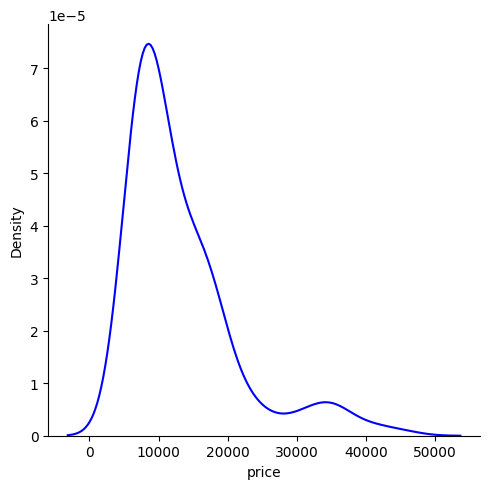

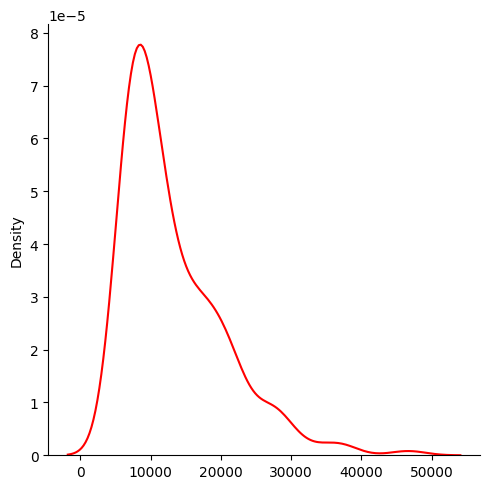

In [125]:
# trực quan
ax1 = sns.displot(
    y,
    kind='kde',
    color='blue'
)

# distribution plot cho y dự đoán
ax2 = sns.displot(
    yhat,
    kind='kde',
    color='red'
)

<Axes: xlabel='price', ylabel='Density'>

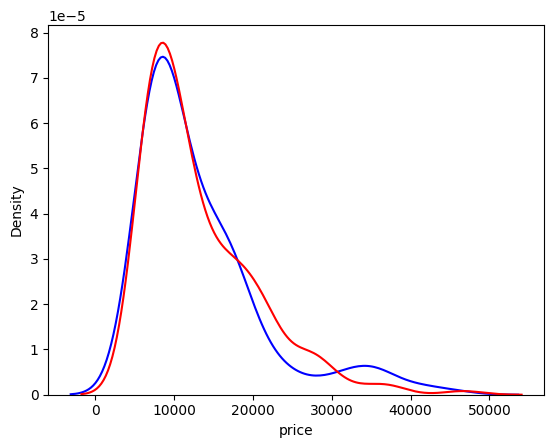

In [126]:
# đối chiếu
ax1 = sns.kdeplot(y, color="blue")
sns.kdeplot(yhat, color='red', ax=ax1)

#### Nhận Xét

- Với bậc 2, chúng ta có kết quả dự đoán sát với thực tế hơn mô hình dự đoán tuyến tính đơn biến.

#### Nhiều Bậc Hơn (Bậc 4)

In [127]:
# features
X4 = df_theory[['horsepower', 'curb-weight']]
y = df_theory['price']

In [128]:
# khai báo biến đổi
pf4 = PolynomialFeatures(degree=4, include_bias=False)
X4_pf = pf4.fit_transform(X4)

In [129]:
# shape
print("Thực tế: ", X4.shape)
print("Biến đổi: ", X4_pf.shape)

Thực tế:  (201, 2)
Biến đổi:  (201, 14)


In [130]:
# khai báo mô hình
m4 = LinearRegression()
# xây dựng mô hình
m4.fit(X4_pf, y)

LinearRegression()

In [131]:
# dự đoán
y4hat = m4.predict(X4_pf)

<Axes: xlabel='price', ylabel='Density'>

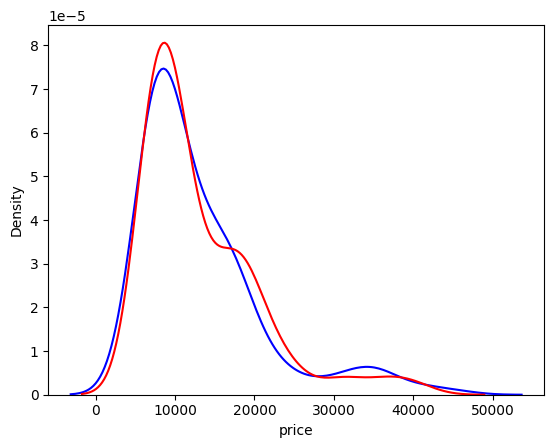

In [132]:
# đánh giá trực quan
ax1 = sns.kdeplot(
    y,
    color='blue'
)
sns.kdeplot(y4hat, color='red', ax=ax1)

### Quy Trình 3 Bước

1. Chuẩn hóa (Normalize)
2. Biến đổi (Transform)
3. Xây dựng (Fit)

#### Thực Hiện

In [133]:
X5 = df_theory[['horsepower', 'curb-weight']]
y = df_theory['price']

## Bước 1. Chuẩn hóa
from sklearn.preprocessing import StandardScaler
ss5 = StandardScaler()
X5_ss = ss5.fit_transform(X5)

## Bước 2. Biến đổi
pf5 = PolynomialFeatures(degree=2, include_bias=False)
X5_pf = pf5.fit_transform(X5_ss)

print("Thực tế: ", X5.shape)
print("Biến đổi: ", X5_pf.shape)

## Bước 3. Xây dựng
m5 = LinearRegression()
m5.fit(X5_pf, y)

# dự đoán
y5hat = m5.predict(X5_pf)

Thực tế:  (201, 2)
Biến đổi:  (201, 5)


<Axes: xlabel='price', ylabel='Density'>

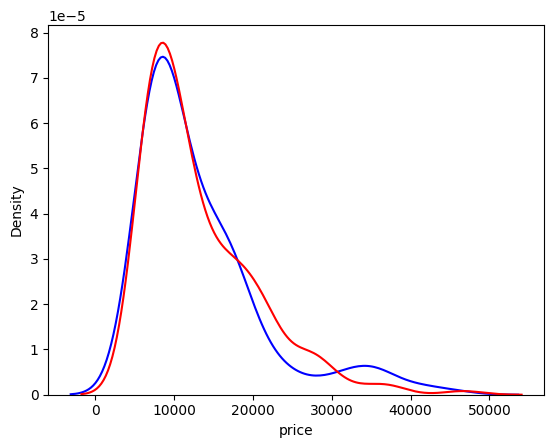

In [134]:
# trực quan và đánh giá
ax1 = sns.kdeplot(
    y,
    color='blue'
)
sns.kdeplot(
    y5hat,
    color='red',
    ax=ax1
)

#### Nhận Xét

Kết quả trực quan cho thấy kết quả sai khác chút ít với mô hình m4 đã dựng "thủ công" ở trên.

- Kết quả tốt hơn ở ngưỡng < 20000
- Có sự sai lệch nhiều hơn từ 20000 - 45000

## Pipeline

- (Bán) tự động hóa Quy Trình 3 Bước ở trên.

In [135]:
# import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [136]:
# pipeline constructor
pl_inputs = [('chuanhoa', StandardScaler()),
             ('hoiquy', PolynomialFeatures(degree=2, include_bias=False)),
             ('dudoan', LinearRegression())
]

# khai bao đối tượng
pl1 = Pipeline(pl_inputs)

In [137]:
# xây dựng
pl1.fit(X4, y)

Pipeline(steps=[('chuanhoa', StandardScaler()),
                ('hoiquy', PolynomialFeatures(include_bias=False)),
                ('dudoan', LinearRegression())])

In [138]:
# dự đoán với giá trị thực tế
pl1.predict([[111, 2548]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([12302.83552899])

In [139]:
# dự đoán
yplhat = pl1.predict(X4)

<Axes: xlabel='price', ylabel='Density'>

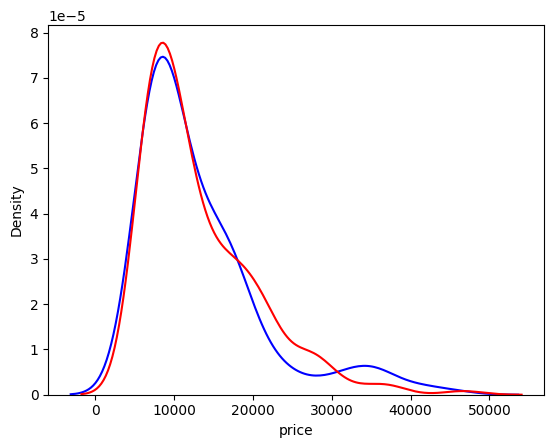

In [140]:
# đối chiếu trực quan
ax1 = sns.kdeplot(y, color='blue')
sns.kdeplot(yplhat, color='red', ax=ax1)

### Nhận Xét

Kết quả trực quan cho thấy:

- Tương đồng hoàn toàn với kết quả của Quy Trình 3 Bước đã thực hiện thủ công trước đó.

## Bài Tập Áp Dụng

- p72
- Xây dựng mô hình hồi quy đa thức cho 4 biến bậc 3.